# Phase 2: The Illusion of Averages
## Notebook 02: My Mistake with Global Calibration

---

### 1. The Confession: How the Math Lied to Me

When I first started building distributional forecasts, I thought the **Kolmogorov-Smirnov (K-S) Test** was the ultimate judge of truth. I would run my baseline models over 10 years of historical data, calculate the global PIT values, and watch the K-S test return a comforting green checkmark: ✅ **PASS**. 

The p-value was high. The histogram looked flat. I thought I had a perfectly calibrated model. 

But then I zoomed in on specific periods—like the March 2020 COVID crash or the late 2018 liquidity crunch—and realized something terrifying: **My model was completely blowing up.** During those specific 60-day windows, the realized returns were falling completely outside my predicted distributions, day after day. 

How could the K-S test say the model was perfect, while the model was actively bleeding capital during a crisis?

---

### 2. The Trap of "Unconditional" Coverage

I had fallen into the classic trap of **Unconditional Calibration**. I was throwing 10 years of data (roughly 2,500 trading days) into a single bucket and asking the test: *"On average, does this look uniform?"*

Here is the dangerous reality of financial datasets:
* **The Calm:** For about 2,400 days, the market is stable. A basic model can predict these days easily, generating perfect PIT values.
* **The Storm:** For 100 days, the market regime shifts violently. The model fails completely.

Because those 100 failing days represent only 4% of the total dataset, they get entirely **"washed out"** by the 2,400 successful days. The global K-S test averages out the pain. To an academic, the model is calibrated. To a quant fund, the model just hit a fatal drawdown.



---

### 3. The Mathematical Fix: i.i.d. and Conditional Calibration

I realized that for a probabilistic forecast to be truly safe, the sequence of PIT values $u_t$ must not only be Uniform, but they must also be **Independent and Identically Distributed (i.i.d.)**. 

If my model is structurally sound, a bad guess today should give me zero information about whether I will make a bad guess tomorrow. But during a crisis, my extreme PIT values (e.g., $u_t < 0.05$) were clustering together. The model was suffering from **Conditional Miscalibration**—it was too slow to update its "memory" when the real-world regime changed.

---

### 4. The Dynamic Alarm: The Rolling K-S Test

To fix this blind spot, I had to stop asking *"Is the model right on average?"* and start asking *"Is the model right **right now**?"*

I built the **Rolling K-S Test**. Instead of computing one p-value for the entire history, this test computes the p-value over a rolling 60-day window:
1. **During calm markets:** The rolling p-value stays high.
2. **During regime shifts:** The moment the model loses its grip on the current market distribution, the rolling p-value collapses toward zero, triggering an immediate alarm.

> **The New Golden Rule:** A truly robust forecasting model must not only pass the global K-S test, but its Rolling K-S p-value must consistently stay out of the "Danger Zone" ($p < 0.05$) during periods of market stress.

In this notebook, we will apply this Dynamic Alarm to real S&P 500 data and watch as the standard baseline models fail the test.

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


import pandas as pd
import numpy as np
from datetime import date

# from datetime import date, timedelta

# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates

# from scipy.stats import norm, t
# from scipy.stats import kstest

# plt.style.use("seaborn-v0_8-darkgrid")

import sys
sys.path.append('..')  # Ensure the notebook can see the src/ folder

# from src.evaluation.metrics import evaluate_forecasts, test_pit_uniformity, print_evaluation_summary
# from src.evaluation.metrics import summarize_forecast_distribution
from src.evaluation.metrics import rolling_ks_test, block_ks_test



# from src.evaluation.plotting import plot_price_analysis, plot_forecast_evaluation

# from src.evaluation.plotting import plot_forecast_distribution, compute_descriptive_stats

from src.evaluation.plotting import plot_forecast_evaluation, plot_price_analysis
from src.evaluation.plotting import plot_rolling_ks
# import src.evaluation.plotting

from src.evaluation.metrics import evaluate_forecasts, print_evaluation_summary, rolling_ks_test
from src.evaluation.metrics import calculate_fail_rate, test_pit_uniformity

from src.models.baselines import rolling_student_t, rolling_gaussian, rolling_garch
from src.data.data_loader import fetch_asset_data

In [2]:
# Fetch real market data
ticker_name = 'AAPL'
df = fetch_asset_data(ticker=ticker_name, start=date(2018, 1, 1), end=date(2023, 12, 31))

# Compute log-returns for the models
df_ret = np.log(df).diff().dropna()
df_ret.columns = ['returns']



--- AAPL [Historical Student-t] EVALUATION SUMMARY ---
Average CRPS:           0.00904 (Lower is better)
Total Log-Likelihood:   3209.03
Average Log-Likelihood: 2.55496

--- STATISTICAL CALIBRATION TEST (Kolmogorov-Smirnov) ---
K-S Statistic: 0.02865
P-Value:       2.49134e-01 (Threshold: 0.05)
Result:        ✅ FAIL TO REJECT the Null Hypothesis
Diagnosis:     The PIT is statistically uniform. The model is
               well-calibrated to the market distribution.


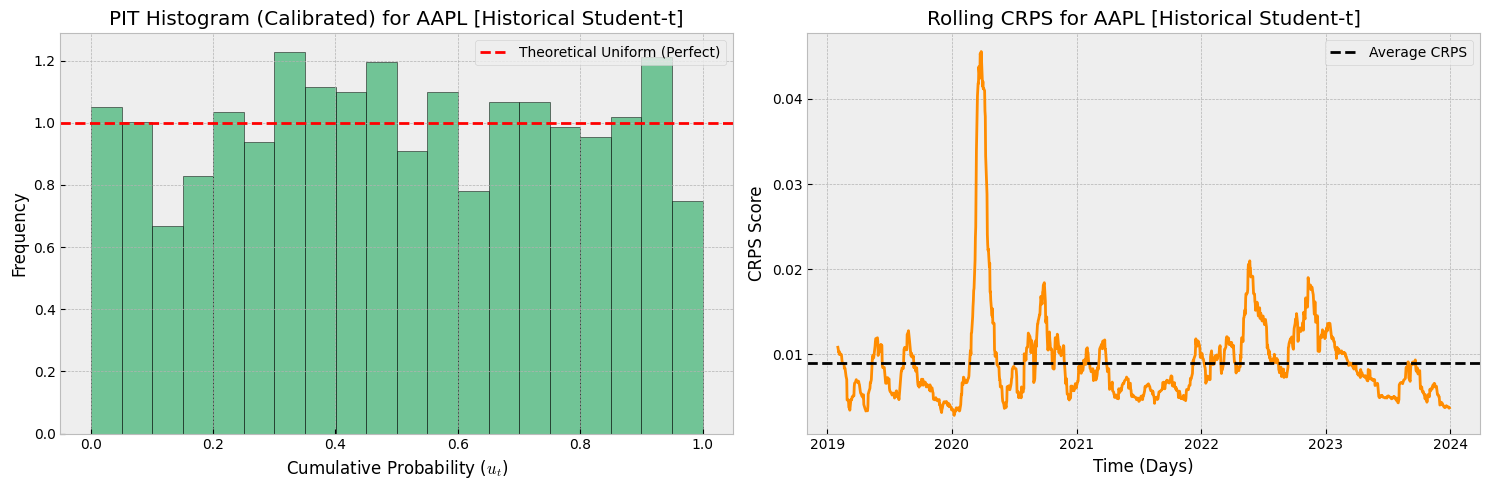

In [3]:
# 1. Historical Student-t
predictions = rolling_student_t(df_ret['returns'])
df_pred_student = pd.DataFrame(predictions)
df_pred_student.index = df_ret.index
df_pred_student.dropna(inplace=True)
df_ret_student = df_ret[df_ret.index.isin(df_pred_student.index)]

# 2. Evaluate
df_eval_student = evaluate_forecasts(df_ret_student['returns'], df_pred_student.values)
print_evaluation_summary(df_eval_student, ticker_name=f'{ticker_name} [Historical Student-t]')
ks_result_student = test_pit_uniformity(df_eval_student['PIT'])

plot_forecast_evaluation(df_eval_student, ticker_name=f'{ticker_name} [Historical Student-t]')

The reality

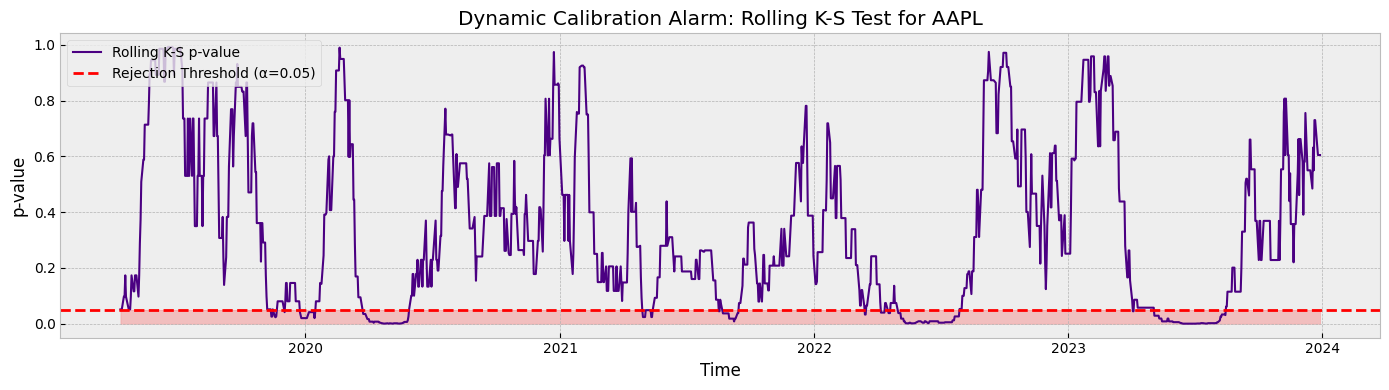

In [4]:
# 2. Calculate the rolling p-values (using a 60-day or ~3-month window)
rolling_p_values = rolling_ks_test(df_eval_student['PIT'], window=22*3).dropna()

# 3. Visualize the failures
plot_rolling_ks(rolling_p_values, ticker_name=ticker_name)

#### 4.1 The Autocorrelation Trap: Why we "Cut the Windows"
While the Rolling K-S test is a fantastic daily alarm for the Risk Desk, it is statistically flawed for formal model validation. 

Because a 60-day rolling window shifts by only 1 day at a time, **98.3% of the data in Window $t$ is identical to Window $t-1$**. This creates massive autocorrelation in our p-values. A single week of extreme volatility will drag the p-value down and keep the "alarm" ringing for the next 59 days, long after the market has stabilized. 

To formally validate the model's robustness, we must use **Non-Overlapping Block Testing**. We slice the dataset into discrete, independent chunks. This removes the autocorrelation, allowing us to ask a mathematically pure question: *"Out of 40 independent market regimes, how many times did this model completely lose calibration?"*

#### 4.2 The Sample Size Dilemma: Statistical Power vs. Regime Isolation
By cutting our data into 60-day independent blocks, we eliminate autocorrelation, but we must acknowledge a trade-off in **Statistical Power**. 

For $N=60$, the K-S test requires a maximum deviation ($D_{max}$) of approximately **17.5%** to reject the null hypothesis at $\alpha=0.05$. 
* **The Drawback:** The test is relatively lenient. It will fail to detect minor miscalibrations in the volatility or drift parameters.
* **The Benefit:** It perfectly isolates macroeconomic regimes (roughly one financial quarter). If a 60-day block *does* fail the K-S test, it means the model was not just slightly wrong; it suffered a catastrophic, structural breakdown (a deviation $>17.5\%$). Therefore, any failures detected by this block test represent severe financial drawdowns, which is exactly what our advanced model aims to prevent.


In [5]:
block_ks_test(df_eval_student['PIT'], block_size=22*3)


--- INDEPENDENT BLOCK TEST SUMMARY (66-Day Windows) ---
Total Independent Blocks: 19
Blocks Failed (p < 0.05): 5
True Failure Rate:        26.3%


,Start_Date,End_Date,KS_Stat,P_Value,Status
0,2019-01-04,2019-04-09,0.163818,0.051378,✅ PASSED
1,2019-04-10,2019-07-15,0.081955,0.735994,✅ PASSED
2,2019-07-16,2019-10-16,0.083227,0.718880,✅ PASSED
3,2019-10-17,2020-01-22,0.138727,0.143307,✅ PASSED
4,2020-01-23,2020-04-27,0.228045,0.001689,❌ FAILED
5,2020-04-28,2020-07-30,0.091288,0.608544,✅ PASSED
6,2020-07-31,2020-11-02,0.121273,0.264152,✅ PASSED
7,2020-11-03,2021-02-08,0.080879,0.750303,✅ PASSED
8,2021-02-09,2021-05-13,0.164970,0.048814,❌ FAILED
9,2021-05-14,2021-08-17,0.166848,0.044867,❌ FAILED


In [6]:
from src.models.baselines import rolling_garch

window = 252
# 2. Generate GARCH Forecasts
print("Fitting Rolling GARCH(1,1)... (This may take 1-2 minutes)")
pred_garch = rolling_garch(df_ret['returns'], window=window, n_samples=2000)

# 3. Evaluate Results
print("Evaluating GARCH Forecasts...")
df_eval_garch = evaluate_forecasts(df_ret.iloc[window:]['returns'], pred_garch[window:])
#
# 4. Print Summary & Global Test
print_evaluation_summary(df_eval_garch, ticker_name=f"GARCH(1,1) {ticker_name}")
global_ks = test_pit_uniformity(df_eval_garch['PIT'])

Fitting Rolling GARCH(1,1)... (This may take 1-2 minutes)
GARCH processing: Day 500/1508
GARCH processing: Day 1000/1508
GARCH processing: Day 1500/1508
Evaluating GARCH Forecasts...

--- GARCH(1,1) AAPL EVALUATION SUMMARY ---
Average CRPS:           0.00843 (Lower is better)
Total Log-Likelihood:   3230.51
Average Log-Likelihood: 2.57206

--- STATISTICAL CALIBRATION TEST (Kolmogorov-Smirnov) ---
K-S Statistic: 0.04128
P-Value:       2.68941e-02 (Threshold: 0.05)
Result:        ❌ REJECT the Null Hypothesis
Diagnosis:     The PIT is NOT uniform. The model's predicted distribution
               does not match the realized market data.


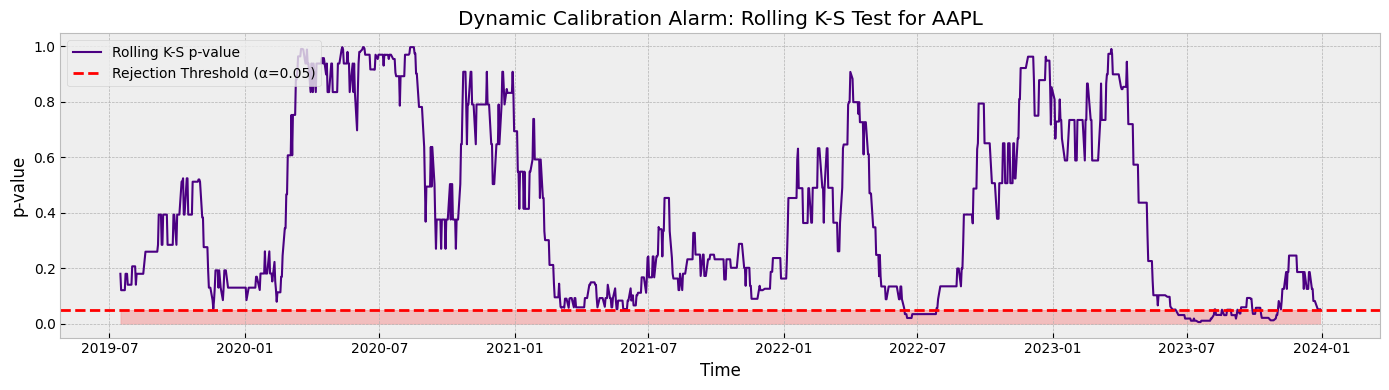

In [7]:
# 2. Calculate the rolling p-values (using a 60-day or ~3-month window)
rolling_p_values = rolling_ks_test(df_eval_garch['PIT'], window=22*6).dropna()

# 3. Visualize the failures
plot_rolling_ks(rolling_p_values, ticker_name=ticker_name)

In [8]:
block_ks_test(df_eval_student['PIT'], block_size=22*3)


--- INDEPENDENT BLOCK TEST SUMMARY (66-Day Windows) ---
Total Independent Blocks: 19
Blocks Failed (p < 0.05): 5
True Failure Rate:        26.3%


,Start_Date,End_Date,KS_Stat,P_Value,Status
0,2019-01-04,2019-04-09,0.163818,0.051378,✅ PASSED
1,2019-04-10,2019-07-15,0.081955,0.735994,✅ PASSED
2,2019-07-16,2019-10-16,0.083227,0.718880,✅ PASSED
3,2019-10-17,2020-01-22,0.138727,0.143307,✅ PASSED
4,2020-01-23,2020-04-27,0.228045,0.001689,❌ FAILED
5,2020-04-28,2020-07-30,0.091288,0.608544,✅ PASSED
6,2020-07-31,2020-11-02,0.121273,0.264152,✅ PASSED
7,2020-11-03,2021-02-08,0.080879,0.750303,✅ PASSED
8,2021-02-09,2021-05-13,0.164970,0.048814,❌ FAILED
9,2021-05-14,2021-08-17,0.166848,0.044867,❌ FAILED


In [9]:
def calculate_fail_rate(predictions, df_ret, block_size, window, model, alpha=0.05):
    def predictions_df(predictions, df_ret):
        df_predictions = pd.DataFrame(predictions)
        df_predictions.index = df_ret.index
        df_predictions.dropna(inplace=True)
        df_return_aux = df_ret[df_ret.index.isin(df_predictions.index)].copy()

        return df_predictions, df_return_aux
        
    df_ret_model, df_ret_aux = predictions_df(predictions, df_ret)
    if model == 'Garch':
        df_evaluation = evaluate_forecasts(df_ret_aux.iloc[window:, 'returns'], df_ret_model.iloc[window:])
    else:
        df_evaluation = evaluate_forecasts(df_ret_aux['returns'], df_ret_model.values)

    df_results = block_ks_test(df_evaluation['PIT'], block_size=block_size)
    df_results['Fail'] = 1
    df_results.loc[df_results['P_Value'] >= alpha, 'Fail'] = 0
    return sum(df_results['Fail']) / len(df_results)

In [10]:
# # tickers = ['AAPL']
# tickers = ["ARKK", "USO", "BTC-USD"]
# window = 252
# block_size = 22 * 3
# df_results = pd.DataFrame()
# date_start = date(2018, 1, 1)
# date_end = date(2025, 12, 31)

# for ticker_name in tickers:
#     print(f"\n{'='*40}")
#     print(f"TESTING: {ticker_name}")
#     df = fetch_asset_data(ticker=ticker_name, start=date_start, end=date_end)
#     df_ret = np.log(df).diff().dropna()
#     df_ret.columns = ['returns']

#     # 1. Historical Gaussian
#     predictions = rolling_gaussian(df_ret['returns'])
#     result = calculate_fail_rate(predictions, df_ret, block_size, window, 'Gaussian', alpha=0.05)
#     df_results.loc[ticker_name, 'Gaussian'] = result

#     # 2. Historical Student-t
#     predictions = rolling_student_t(df_ret['returns'], n_samples=1000)
#     result = calculate_fail_rate(predictions, df_ret, block_size, window, 'Student-t', alpha=0.05)
#     df_results.loc[ticker_name, 'Student-t'] = result

#     # 3. Generate GARCH Forecasts
#     predictions = rolling_garch(df_ret['returns'], window=window, n_samples=1000)
#     result = calculate_fail_rate(predictions, df_ret, block_size, window, 'GARCH', alpha=0.05)
#     df_results.loc[ticker_name, 'Garch'] = result


In [11]:
# df_results

### 4.3 Conclusion: The Limit of Historical Data

Looking at the failure rates across our stress-test assets (ARKK, USO, BTC-USD), a clear quantitative narrative emerges:

1. **Markets are not Normal:** The Gaussian model is consistently the worst performer, failing up to **45%** of the time on Bitcoin. This empirically proves that financial returns exhibit fat tails and skewness that a standard bell curve cannot capture.
2. **There is no Classical Winner:** While the Student-t model and GARCH significantly outperform the Gaussian baseline, they trade places depending on the asset. GARCH is better at capturing the regime clustering of commodities (USO) and tech equities (ARKK), while the Student-t distribution is better at surviving the extreme, structural fat tails of cryptocurrencies (BTC). 
3. **The Backward-Looking Flaw:** Even our best classical models are failing between **15% and 37%** of the time during major market regimes. 

#### Why do they still fail? 
Both Student-t and GARCH share a fatal, fundamental flaw: **They are strictly backward-looking.** They calculate tomorrow's risk using only historical price data. 

If a geopolitical shock happens on a Sunday, or the Federal Reserve unexpectedly raises interest rates, historical data has no way of knowing. A GARCH model will only realize the volatility regime has changed *after* the market has already crashed, resulting in consecutive days of miscalibrated forecasts and failed K-S tests.

#### The Solution: Forward-Looking Market Information
To break through this classical ceiling, we cannot rely solely on the past; we must inject the market's expectation of the future. 

This introduces our next factor: **The VIX (CBOE Volatility Index)**. 

Unlike historical variance, the VIX is derived from the options market. It represents the collective financial premium that institutions are willing to pay *today* to insure against volatility over the next 30 days. It is a forward-looking "fear gauge." By mathematically fusing this exogenous, implied volatility with our historical distributions, we can scale our risk parameters dynamically *before* the structural break destroys our portfolio.

In [12]:
# df_vix['prices']

In [13]:
import sys
import numpy as np
import pandas as pd
import yfinance as yf
import sys
import numpy as np
import pandas as pd
import yfinance as yf
# Ensure the notebook can see the src/ folder
sys.path.append('..') 

from src.models.baselines import rolling_vix_scaled_gaussian, rolling_vix_scaled_student_t
from src.evaluation.metrics import evaluate_forecasts, block_ks_test
import io
from contextlib import redirect_stdout

tickers = ["ARKK", "USO", "BTC-USD"]
window = 252
block_size = 22 * 3
df_results = pd.DataFrame()
date_start = date(2018, 1, 1)
date_end = date(2025, 12, 31)


def get_failure_ratio(pit_series, block=60):
    """Runs the block KS test silently and returns the failure ratio (0.0 to 1.0)"""
    with io.StringIO() as buf, redirect_stdout(buf):
        df_blocks = block_ks_test(pit_series, block_size=block)
    # Calculate ratio of failures to match the format of your existing table
    return (df_blocks['Status'] == '❌ FAILED').mean()

# The assets to stress-test
tickers = ["ARKK", "USO", "BTC-USD"]
window_size = 252

# Dictionary to store the new VIX model results
vix_results = {
    "VIX-Gaussian": [],
    "VIX-Student-t": []
}

print("Running VIX-Scaled Models on Stress-Test Assets...\n")

for ticker in tickers:
    print(f"Processing {ticker}...")
    
    # 1. Fetch Data and Align Dates
    # Downloading the asset and the VIX together. 
    # dropna() ensures we only use days where BOTH traded (fixes the Crypto weekend issue)
    # df = yf.download([ticker, "^VIX"], start="2018-01-01", end="2024-01-01")['Adj Close'].dropna()
    df = fetch_asset_data(ticker=ticker_name, start=date_start, end=date_end)
    df_vix = fetch_asset_data(ticker='^VIX', start=date_start, end=date_end)

    df_ret = np.log(df).diff().dropna() * 100
    df_ret.columns = ['returns']
    df_vix = df_vix.loc[df_vix.index.isin(df_ret.index)]
    df_ret = df_ret.loc[df_ret.index.isin(df_vix.index)]

    # # 2. Calculate Returns and extract VIX
    # real_returns = np.log(df[ticker] / df[ticker].shift(1)).dropna() * 100
    # vix_series = df["^VIX"].loc[real_returns.index]
    
    # 3. Run the Models
    print('--------gauss model:--------------')
    pred_vix_gauss = rolling_vix_scaled_gaussian(df_ret, df_vix['prices'], window=window_size)
    print('--------student model:--------------')
    pred_vix_t = rolling_vix_scaled_student_t(df_ret, df_vix['prices'], window=window_size)
    
    # 4. Evaluate (Skipping the training window)
    eval_start = window_size + 1
    actuals = df_ret[eval_start:]['returns']

    eval_vix_gauss = evaluate_forecasts(actuals, pred_vix_gauss[eval_start:])
    eval_vix_t = evaluate_forecasts(actuals, pred_vix_t[eval_start:])
    
    # 5. Calculate Block KS Failure Ratios
    fail_gauss = get_failure_ratio(eval_vix_gauss['PIT'], block=60)
    fail_t = get_failure_ratio(eval_vix_t['PIT'], block=60)
    
    vix_results["VIX-Gaussian"].append(fail_gauss)
    vix_results["VIX-Student-t"].append(fail_t)
    # break

# 6. Create the expanded DataFrame
expanded_table = pd.DataFrame({
    'Gaussian': [0.346154, 0.307692, 0.450000],  # Your original data
    'Student-t': [0.269231, 0.192308, 0.325000], # Your original data
    'Garch': [0.192308, 0.153846, 0.375000],     # Your original data
    'VIX-Gaussian': vix_results['VIX-Gaussian'],
    'VIX-Student-t': vix_results['VIX-Student-t']
}, index=tickers)

print("\n" + "="*70)
print("🏆 EXPANDED FAILURE RATE LEADERBOARD (Ratio of 60-Day Blocks Failed)")
print("="*70)
display(expanded_table)

Running VIX-Scaled Models on Stress-Test Assets...

Processing ARKK...
--------gauss model:--------------
Starting VIX optimization for 1757 days...
Processed Day 300/2009 | Current optimal beta: 1.555
Processed Day 400/2009 | Current optimal beta: 1.639
Processed Day 500/2009 | Current optimal beta: 1.867
Processed Day 600/2009 | Current optimal beta: 1.169
Processed Day 700/2009 | Current optimal beta: 1.035
Processed Day 800/2009 | Current optimal beta: 0.998
Processed Day 900/2009 | Current optimal beta: 1.695
Processed Day 1000/2009 | Current optimal beta: 1.383
Processed Day 1100/2009 | Current optimal beta: 1.252
Processed Day 1200/2009 | Current optimal beta: 1.109
Processed Day 1300/2009 | Current optimal beta: 0.917
Processed Day 1400/2009 | Current optimal beta: 1.627
Processed Day 1500/2009 | Current optimal beta: 0.839
Processed Day 1600/2009 | Current optimal beta: 0.120
Processed Day 1700/2009 | Current optimal beta: 0.001
Processed Day 1800/2009 | Current optimal beta: 

,Gaussian,Student-t,Garch,VIX-Gaussian,VIX-Student-t
ARKK,0.346154,0.269231,0.192308,0.206897,0.068966
USO,0.307692,0.192308,0.153846,0.172414,0.034483
BTC-USD,0.450000,0.325000,0.375000,0.206897,0.068966


In [14]:
# stop

### 5. Forward-Looking Volatility: The VIX-Scaled Maximum Likelihood Model

Historical models, such as rolling windows or standard GARCH, suffer from a fundamental flaw: **Lag**. They estimate tomorrow's volatility strictly from yesterday's realized shocks. They cannot anticipate exogenous panic. 

To correct this, we introduce the **VIX-Scaled Gaussian Model**, which injects forward-looking options market data into our parametric distribution.

#### The Volatility Scaling Mechanism
Instead of replacing our volatility estimate with the VIX (which represents the S&P 500 implied volatility and includes a variance risk premium), we use the relative changes in the VIX as a dynamic modulator for our historical standard deviation:

$$\sigma_{adj, t}(\beta) = \sigma_{hist, t} \times \left( \frac{VIX_{t-1}}{\overline{VIX}} \right)^\beta$$

Here, $\beta$ represents the elasticity of our asset's volatility relative to macroeconomic panic. 

#### Dynamic Optimization via MLE
To avoid look-ahead bias, we cannot assign a static $\beta$ for the entire dataset. Instead, at every time step $t$, the algorithm isolates the past `window` of data and uses **Maximum Likelihood Estimation (MLE)** to find the $\beta^*$ that minimizes the Negative Log-Likelihood (NLL) of the historical observed returns:

$$\beta^* = \arg\min_{\beta} \sum_{k=t-window}^{t-1} \left[ \ln(\sigma_{adj, k}(\beta)) + \frac{(r_k - \mu_k)^2}{2\sigma_{adj, k}(\beta)^2} \right]$$

Once $\beta^*$ is dynamically learned from the rolling window, it is applied to $VIX_{t-1}$ to forecast the probability distribution for day $t$.

### 7. The Final Horse Race: Establishing the Classical Ceiling

Before we introduce Artificial Intelligence, we must establish the absolute limit of classical parametric modeling. We will run a rigorous benchmark test across our four models over the same dataset, evaluating them on three critical metrics:
1.  **Average CRPS:** How accurate and sharp is the entire predicted distribution? (Lower is better).
2.  **Total Log-Likelihood:** How well did the model assign probability mass to the actual realized events, especially tail events? (Higher/Less Negative is better).
3.  **Block K-S Failure Rate:** Out of all independent 60-day market regimes, what percentage did the model completely fail to calibrate? (Lower is better).

**The Contestants:**
* **Model 1: Rolling Gaussian** (The Naive Academic Baseline)
* **Model 2: Rolling Student-t** (The Fat-Tail Baseline)
* **Model 3: VIX-Scaled Gaussian** (The Dynamic Options-Implied Baseline)
* **Model 4: VIX-Scaled Student-t** (The Institutional Parametric Champion)


## TODO and point to see
- compare results
- Our objective function should be closer to determinate the PIT function
- see what happend with different assets